<a href="https://colab.research.google.com/github/LeonardoVS-dev/Fundamentos/blob/main/pivot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pivot e pivot_table

In [18]:
import pandas as pd
import numpy as np

dados_eleitorais = pd.read_csv("/content/votacao_candidato_munzona_2024_RR LIMPADO_CORRIGIDO.csv", encoding="latin-1", sep=";")

In [25]:
# Remoção de colunas indesejadas / desnecessárias com o drop()
# 13 é o código de vereador, 11 é o de prefeito

tabela_eleicao = dados_eleitorais.groupby(["NM_MUNICIPIO", "NR_ZONA", "NM_CANDIDATO", "NM_URNA_CANDIDATO", "NR_PARTIDO", "SG_PARTIDO"]).sum().reset_index()
tabela_eleicao.drop(["NM_MUNICIPIO", "NR_ZONA", "NM_CANDIDATO", "NM_URNA_CANDIDATO", "NR_PARTIDO", "SG_PARTIDO"], axis=1, inplace=True)
tabela_eleicao.head(10)

,CD_CARGO,NM_PARTIDO,QT_VOTOS_NOMINAIS
0,13,Partido Democrático Trabalhista,267
1,13,Partido Social Democrático,660
2,13,REPUBLICANOS,352
3,13,Partido Social Democrático,112
4,13,REPUBLICANOS,557
5,13,PROGRESSISTAS,7
6,13,Podemos,130
7,13,Partido Social Democrático,470
8,13,Podemos,159
9,13,REPUBLICANOS,164


In [27]:
# Aplicação do pivot_table, com base na tabela anterior

# Aqui, ele mostra a soma (através do aggfunc) de votos de todos os candidatos a vereador e
# prefeito por nome do partido, com o pivot_table atuando para mostrar os
# códigos de cargo como colunas
a = tabela_eleicao.pivot_table(index="NM_PARTIDO", columns="CD_CARGO", values="QT_VOTOS_NOMINAIS", aggfunc="sum")#.head(5)

# Essa linha, através do Numpy, serve para trocar todos os NaN (dos candidatos que não receberam
# votos) por None.
replaced_df = a.replace({np.nan: None})
replaced_df

CD_CARGO,11,13
NM_PARTIDO,,
AVANTE,None,2092.0
Cidadania,3117.0,2263.0
Democracia Cristã,None,15395.0
Movimento Democrático Brasileiro,134526.0,31956.0
PROGRESSISTAS,39521.0,44068.0
Partido Comunista do Brasil,None,279.0
Partido Democrático Trabalhista,7267.0,34259.0
Partido Liberal,5167.0,8863.0
Partido Novo,449.0,5192.0


<Axes: xlabel='NM_PARTIDO'>

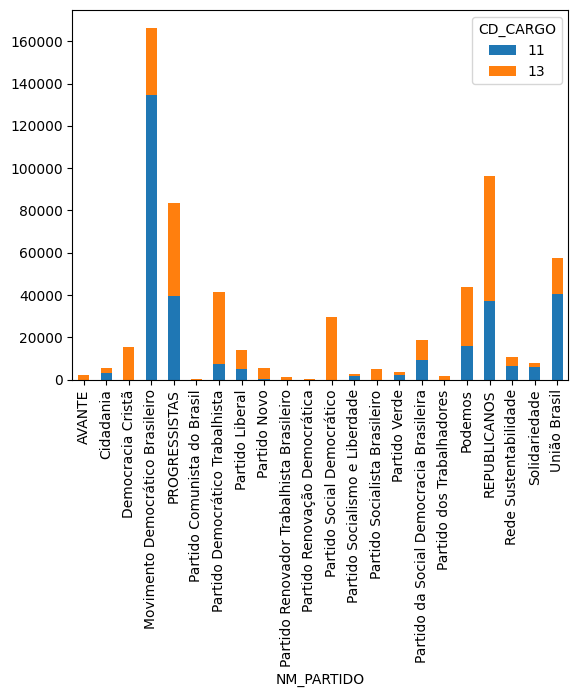

In [28]:
# Plot gráfico com base no DF anterior

# A partir do gráfico, podemos observar a clara dominância do MDB nas eleições
# de 2024 em Roraima
replaced_df.plot(kind="bar", stacked=True)